In [4]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

/tmp/ipykernel_393165/242258884.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_centroid = selected_grid.geometry.centroid.iloc[0]
/tmp/ipykernel_393165/242258884.py:61: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


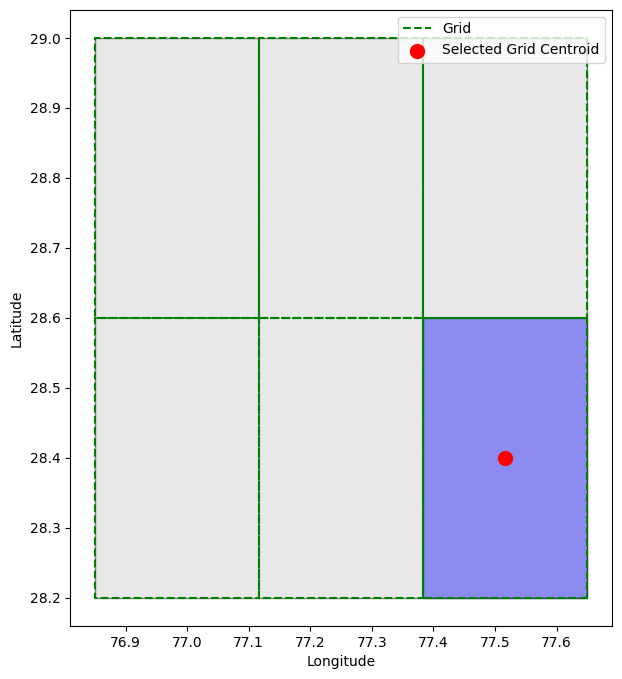

Selected grid saved as GeoJSON: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/delhi_airshed_small.geojson


In [8]:



region = "delhi_airshed"  # Change this to the desired region
# Load airshed data
# airshed_path = f"/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson
airshed_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/shapes/delhi_airshed.geojson"
gdf_airshed = gpd.read_file(airshed_path)

# Save original CRS (EPSG:4326)
original_crs = gdf_airshed.crs

# Reproject to Equal-Area CRS (EPSG:6933)
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Get bounding box in meters
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds

# Divide into 8 equal parts (4 columns × 2 rows)
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

# Create grid cells
grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Convert grid to GeoDataFrame and clip with the airshed
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Convert back to original CRS
grid_gdf = grid_gdf.to_crs(original_crs)
gdf_airshed = gdf_airshed.to_crs(original_crs)

# # Select the **third grid cell in the upper row** (index 2 in row 0)
selected_grid = grid_gdf.iloc[[4]]  # Keep as GeoDataFrame

# Get centroid of selected grid cell
selected_centroid = selected_grid.geometry.centroid.iloc[0]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot airshed
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="lightgray", alpha=0.5, label="Delhi Airshed")

# Plot grid in green
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=1.5, linestyle="--", label="Grid")

# Highlight the selected grid cell in blue
selected_grid.plot(ax=ax, facecolor="blue", edgecolor="black", alpha=0.4, label="Selected Grid")

# Mark the centroid
ax.scatter(selected_centroid.x, selected_centroid.y, color="red", marker="o", s=100, label="Selected Grid Centroid")

# Customize plot
# ax.set_title("Delhi Airshed with Selected Upper Third Grid Cell", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

# Define output GeoJSON path
output_geojson_path = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/{region}_small.geojson"

# Save the selected grid cell as a GeoJSON file
selected_grid.to_file(output_geojson_path, driver="GeoJSON")

print(f"Selected grid saved as GeoJSON: {output_geojson_path}")


/tmp/ipykernel_393165/193954641.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
/tmp/ipykernel_393165/193954641.py:51: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ax.scatter(gdf_ncr_clipped.centroid.x, gdf_ncr_clipped.centroid.y,
/tmp/ipykernel_393165/193954641.py:59: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


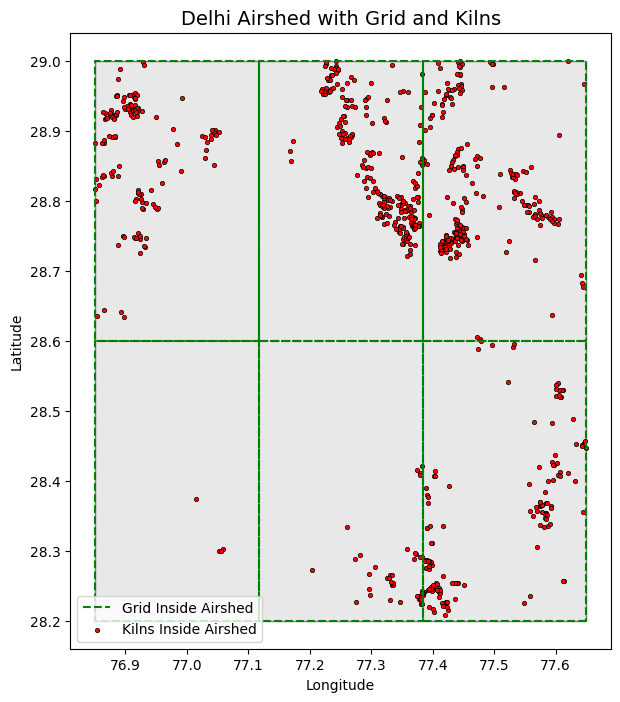

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

# Load GeoJSONs (EPSG:4326)
# airshed_path = "/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson"
ncr_data_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/after_hand_validation_data/india_v5/final/india_v5.geojson"

gdf_airshed = gpd.read_file(airshed_path)
gdf_ncr = gpd.read_file(ncr_data_path)

# Reproject to Equal-Area CRS (World Equidistant Cylindrical EPSG:6933)
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Get bounding box in meters
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds

# Divide into 8 equal parts (4 columns × 2 rows)
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

# Create grid cells
grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Convert to GeoDataFrame and clip grid to the airshed
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Convert back to EPSG:4326 for plotting
grid_gdf = grid_gdf.to_crs("EPSG:4326")
gdf_airshed = gdf_airshed.to_crs("EPSG:4326")

# Clip kilns data to the airshed
gdf_ncr_clipped = gpd.overlay(gdf_ncr, gdf_airshed, how="intersection")

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Delhi Airshed
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="lightgray", alpha=0.5, label="Delhi Airshed")

# Plot Clipped Grid in Green
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=1.5, linestyle="--", label="Grid Inside Airshed")
gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
ax.scatter(gdf_ncr_clipped.centroid.x, gdf_ncr_clipped.centroid.y, 
           color="red", s=10, edgecolor="black", linewidth=0.5, label="Kilns Inside Airshed")


# Customize plot
ax.set_title("Delhi Airshed with Grid and Kilns", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()

plt.show()


/tmp/ipykernel_393165/1813354609.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
/tmp/ipykernel_393165/1813354609.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped.centroid.plot(ax=ax, color="red", markersize=10, edgecolor="black", linewidth=0.5)


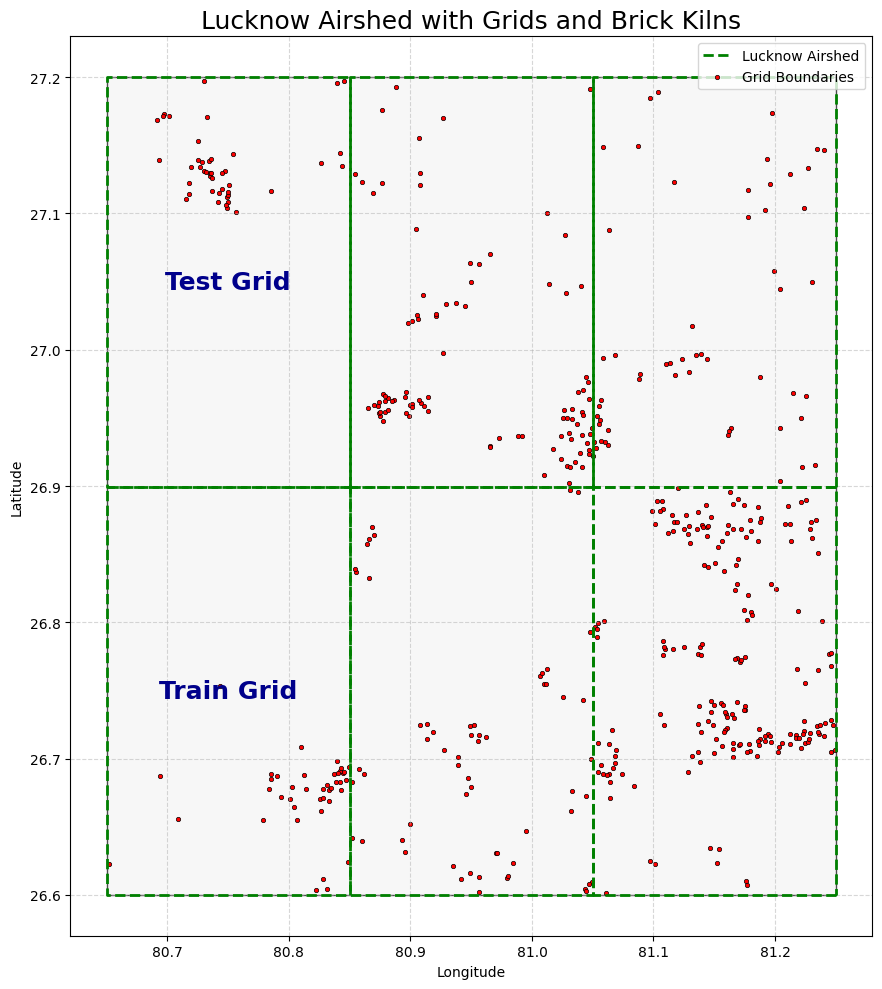

In [17]:
# Re-import necessary libraries after code execution state reset
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

# Define paths
airshed_path = "/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson"
ncr_data_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/after_hand_validation_data/india_v5/final/india_v5.geojson"

# Load GeoJSONs
gdf_airshed = gpd.read_file(airshed_path)
gdf_ncr = gpd.read_file(ncr_data_path)

# Reproject to Equal-Area CRS for consistent spatial splitting
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Bounding box and grid creation
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Create GeoDataFrame of grid and clip
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Annotate the first grid as "Train Grid" and the second as "Test Grid"
grid_gdf["label"] = ""
if len(grid_gdf) > 1:
    grid_gdf.loc[0, "label"] = "Train Grid"
    grid_gdf.loc[1, "label"] = "Test Grid"

# Reproject back to WGS84 for visualization
grid_gdf = grid_gdf.to_crs("EPSG:4326")
gdf_airshed = gdf_airshed.to_crs("EPSG:4326")
gdf_ncr = gdf_ncr.to_crs("EPSG:4326")

# Clip kilns data
gdf_ncr_clipped = gpd.overlay(gdf_ncr, gdf_airshed, how="intersection")
gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="whitesmoke", alpha=0.7)
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=2, linestyle="--")
gdf_ncr_clipped.centroid.plot(ax=ax, color="red", markersize=10, edgecolor="black", linewidth=0.5)

# Add grid labels
for idx, row in grid_gdf.iterrows():
    if row["label"]:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(x, y, row["label"], fontsize=18, fontweight="bold", color="darkblue", ha='center', va='center')

# Customize plot
ax.set_title("Lucknow Airshed with Grids and Brick Kilns", fontsize=18)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor("white")
plt.tight_layout()
plt.legend(["Lucknow Airshed", "Grid Boundaries", "Brick Kilns"], loc="upper right")
# Show plot
plt.tight_layout()
plt.savefig("lucknow_airshed_with_grids_and_kilns.png", dpi=600)
plt.show()


/tmp/ipykernel_393165/294699457.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_centroid = selected_grid.geometry.centroid.iloc[0]
/tmp/ipykernel_393165/294699457.py:61: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


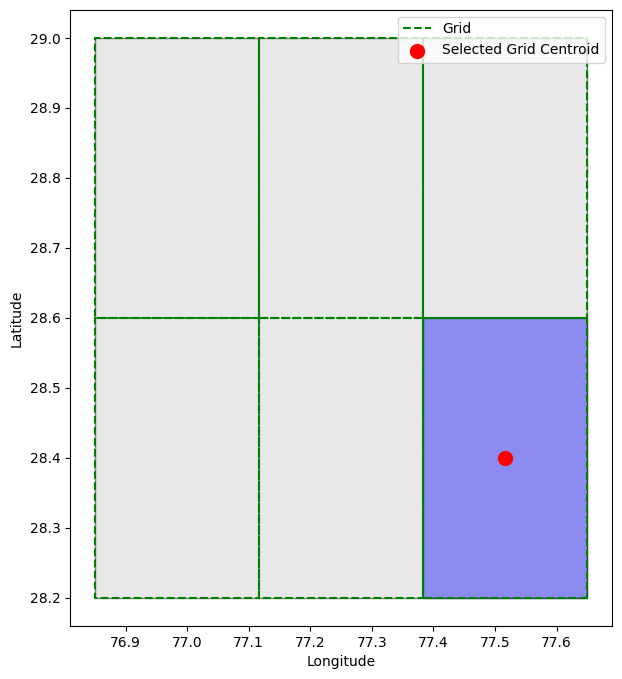

Selected grid saved as GeoJSON: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/delhi_airshed_small.geojson


In [13]:



region = "delhi_airshed"  # Change this to the desired region
# Load airshed data
# airshed_path = f"/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson"
airshed_path = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/shapes/{region}.geojson"
gdf_airshed = gpd.read_file(airshed_path)

# Save original CRS (EPSG:4326)
original_crs = gdf_airshed.crs

# Reproject to Equal-Area CRS (EPSG:6933)
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Get bounding box in meters
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds

# Divide into 8 equal parts (4 columns × 2 rows)
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

# Create grid cells
grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Convert grid to GeoDataFrame and clip with the airshed
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Convert back to original CRS
grid_gdf = grid_gdf.to_crs(original_crs)
gdf_airshed = gdf_airshed.to_crs(original_crs)

# # Select the **third grid cell in the upper row** (index 2 in row 0)
selected_grid = grid_gdf.iloc[[4]]  # Keep as GeoDataFrame

# Get centroid of selected grid cell
selected_centroid = selected_grid.geometry.centroid.iloc[0]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot airshed
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="lightgray", alpha=0.5, label="Delhi Airshed")

# Plot grid in green
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=1.5, linestyle="--", label="Grid")

# Highlight the selected grid cell in blue
selected_grid.plot(ax=ax, facecolor="blue", edgecolor="black", alpha=0.4, label="Selected Grid")

# Mark the centroid
ax.scatter(selected_centroid.x, selected_centroid.y, color="red", marker="o", s=100, label="Selected Grid Centroid")

# Customize plot
# ax.set_title("Delhi Airshed with Selected Upper Third Grid Cell", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

# Define output GeoJSON path
# output_geojson_path = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/{region}_small.geojson"

# Save the selected grid cell as a GeoJSON file
selected_grid.to_file(output_geojson_path, driver="GeoJSON")

print(f"Selected grid saved as GeoJSON: {output_geojson_path}")


/tmp/ipykernel_393165/3217788896.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
/tmp/ipykernel_393165/3217788896.py:52: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped.centroid.plot(ax=ax, color="red", markersize=10, edgecolor="black", linewidth=0.5)


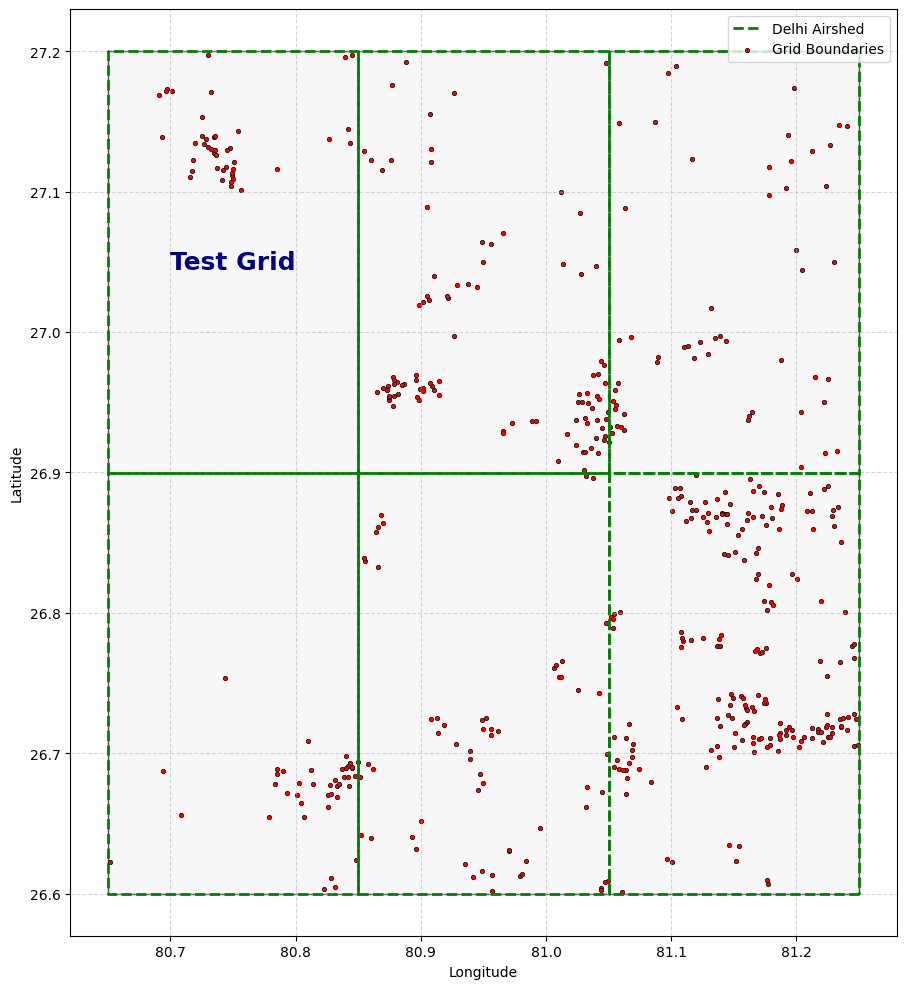

In [39]:
# Re-import necessary libraries after code execution state reset
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

# Define paths
ncr_data_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/after_hand_validation_data/india_v5/final/india_v5.geojson"

# Load GeoJSONs
gdf_airshed = gpd.read_file(airshed_path)
gdf_ncr = gpd.read_file(ncr_data_path)

# Reproject to Equal-Area CRS for consistent spatial splitting
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Bounding box and grid creation
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Create GeoDataFrame of grid and clip
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Annotate the first grid as "Train Grid" and the second as "Test Grid"
grid_gdf["label"] = ""
if len(grid_gdf) > 1:
    # grid_gdf.loc[0, "label"] = "Train Grid"
    grid_gdf.loc[1, "label"] = "Test Grid"

# Reproject back to WGS84 for visualization
grid_gdf = grid_gdf.to_crs("EPSG:4326")
gdf_airshed = gdf_airshed.to_crs("EPSG:4326")
gdf_ncr = gdf_ncr.to_crs("EPSG:4326")

# Clip kilns data
gdf_ncr_clipped = gpd.overlay(gdf_ncr, gdf_airshed, how="intersection")
gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="whitesmoke", alpha=0.7)
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=2, linestyle="--")
gdf_ncr_clipped.centroid.plot(ax=ax, color="red", markersize=10, edgecolor="black", linewidth=0.5)

# Add grid labels
for idx, row in grid_gdf.iterrows():
    if row["label"]:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(x, y, row["label"], fontsize=18, fontweight="bold", color="darkblue", ha='center', va='center')

# Customize plot
# ax.set_title("Delhi Airshed with Grids and Brick Kilns", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor("white")
plt.tight_layout()
plt.legend(["Delhi Airshed", "Grid Boundaries", "Brick Kilns"], loc="upper right")
# Show plot
plt.tight_layout()
plt.savefig("delhi_airshed_with_grids_and_kilns_1.png", dpi=600)
plt.show()


/tmp/ipykernel_393165/4222419400.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid
/tmp/ipykernel_393165/4222419400.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ncr_clipped.centroid.plot(ax=ax, color="red", markersize=10, edgecolor="black", linewidth=0.5)


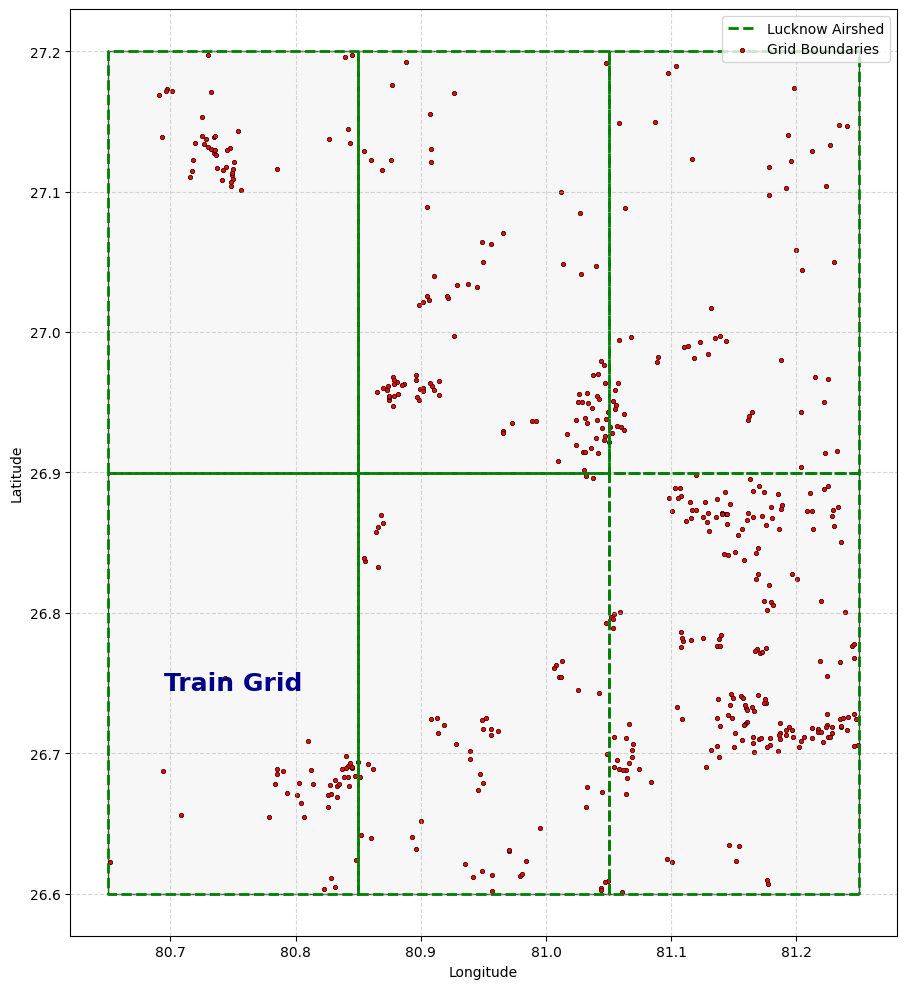

In [24]:
# Re-import necessary libraries after code execution state reset
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

# Define paths
airshed_path = "/home/patel_zeel/kiln_compass_24/regions/shapes/lucknow_airshed.geojson"
ncr_data_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/after_hand_validation_data/india_v5/final/india_v5.geojson"

# Load GeoJSONs
gdf_airshed = gpd.read_file(airshed_path)
gdf_ncr = gpd.read_file(ncr_data_path)

# Reproject to Equal-Area CRS for consistent spatial splitting
gdf_airshed_m = gdf_airshed.to_crs("EPSG:6933")

# Bounding box and grid creation
minx, miny, maxx, maxy = gdf_airshed_m.total_bounds
rows, cols = 2, 3
x_split = np.linspace(minx, maxx, cols + 1)
y_split = np.linspace(miny, maxy, rows + 1)

grid_cells = []
for i in range(cols):
    for j in range(rows):
        cell = box(x_split[i], y_split[j], x_split[i+1], y_split[j+1])
        grid_cells.append(cell)

# Create GeoDataFrame of grid and clip
grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:6933")
grid_gdf = gpd.overlay(grid_gdf, gdf_airshed_m, how="intersection")

# Annotate the first grid as "Train Grid" and the second as "Test Grid"
grid_gdf["label"] = ""
if len(grid_gdf) > 1:
    grid_gdf.loc[0, "label"] = "Train Grid"
    # grid_gdf.loc[1, "label"] = "Test Grid"

# Reproject back to WGS84 for visualization
grid_gdf = grid_gdf.to_crs("EPSG:4326")
gdf_airshed = gdf_airshed.to_crs("EPSG:4326")
gdf_ncr = gdf_ncr.to_crs("EPSG:4326")

# Clip kilns data
gdf_ncr_clipped = gpd.overlay(gdf_ncr, gdf_airshed, how="intersection")
gdf_ncr_clipped["centroid"] = gdf_ncr_clipped.geometry.centroid

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf_airshed.plot(ax=ax, edgecolor="black", facecolor="whitesmoke", alpha=0.7)
grid_gdf.boundary.plot(ax=ax, color="green", linewidth=2, linestyle="--")
gdf_ncr_clipped.centroid.plot(ax=ax, color="red", markersize=10, edgecolor="black", linewidth=0.5)

# Add grid labels
for idx, row in grid_gdf.iterrows():
    if row["label"]:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(x, y, row["label"], fontsize=18, fontweight="bold", color="darkblue", ha='center', va='center')

# Customize plot
# ax.set_title("Lucknow Airshed with Grids and Brick Kilns", fontsize=18)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor("white")
plt.tight_layout()
plt.legend(["Lucknow Airshed", "Grid Boundaries", "Brick Kilns"], loc="upper right")
# Show plot
plt.tight_layout()
plt.savefig("lucknow_airshed_with_grids_and_kilns.png", dpi=600)
plt.show()


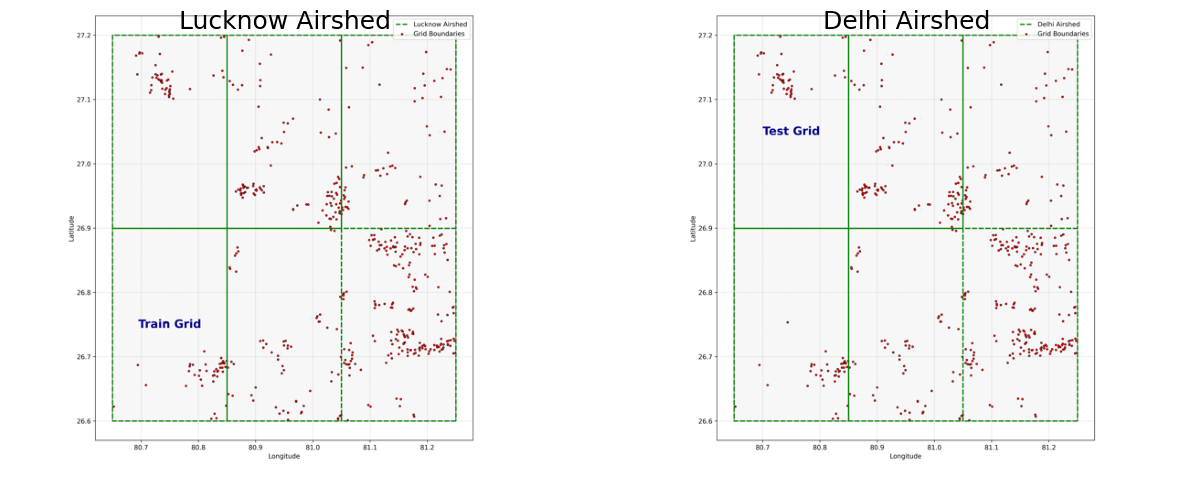

In [43]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Load the two images
img1_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/notebooks/lucknow_airshed_with_grids_and_kilns.png"
img2_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/notebooks/delhi_airshed_with_grids_and_kilns_1.png"

img1 = Image.open(img1_path)
img2 = Image.open(img2_path)

# Ensure both images are the same height
img1 = img1.resize((600, 500))
img2 = img2.resize((600, 500))

# Create a blank canvas to place both images side by side
combined_width = img1.width + img2.width + 80  # extra space for the arrow
combined_height = img1.height
combined_image = Image.new("RGB", (combined_width, combined_height), (255, 255, 255))

# Paste images onto the canvas
combined_image.paste(img1, (0, 0))
combined_image.paste(img2, (img1.width + 80, 0))

# Plot and draw the curved arrow using matplotlib
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(combined_image)

# Draw a curved arrow
arrow = patches.FancyArrowPatch(
    posA=(img1.width, img1.height // 2),
    posB=(img1.width + 80, img2.height // 2),
    connectionstyle="arc3,rad=-0.4",
    arrowstyle='->',
    color='blue',
    linewidth=3
)
# ax.add_patch(arrow)

# Optional: Add text labels
ax.text(img1.width // 2, 20, "Lucknow Airshed", fontsize=18, color='black', ha='center')
ax.text(img1.width + 80 + img2.width // 2, 20, "Delhi Airshed", fontsize=18, color='black', ha='center')
# Show the combined image with the arrow

# plt.figure(figsize=(12, 6))
plt.imshow(combined_image)
plt.axis("off")


plt.tight_layout()
plt.savefig("airshed_comparison_with_arrow.png", dpi=600)

plt.show()
